In [3]:
import openmc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import os

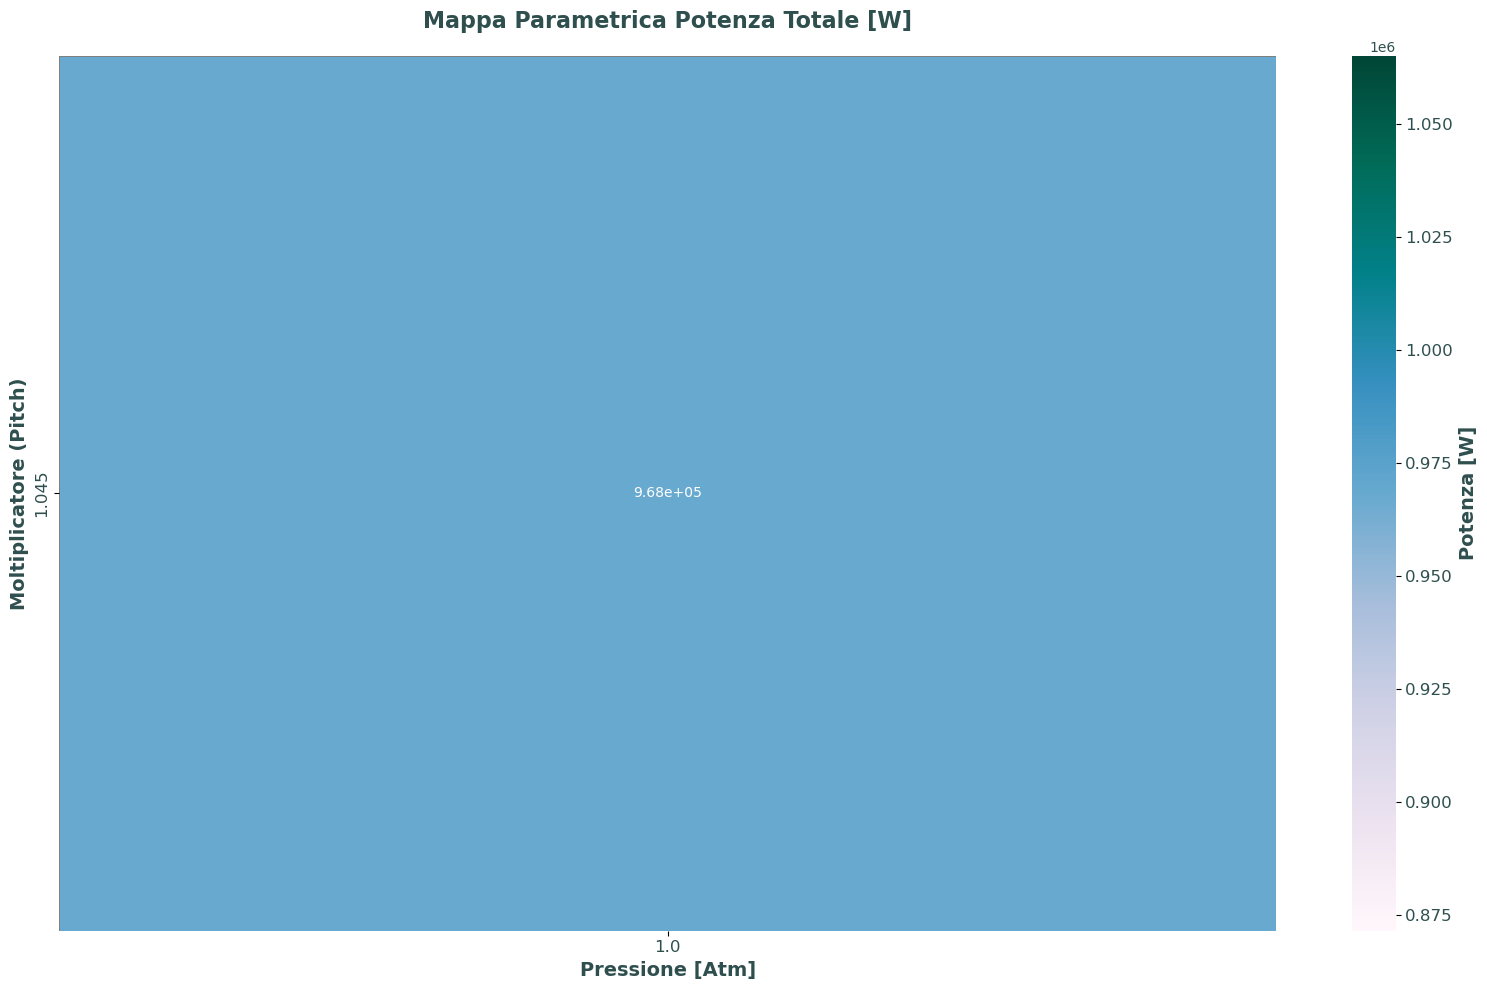

In [4]:
E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione in Joule (~200 MeV)
S_INTENSITY = 2.02e17                   # Fotoni/s dal sincrotrone

def analizza_potenza():
    """Legge i file .h5 nella cartella corrente, estrae le fissioni e calcola la potenza."""
    # Essendo analisi.ipynb dentro 'fixed', i file sono nella current working directory
    file_list = glob.glob("statepoint_case_*.h5")
    
    if not file_list:
        print("Nessun file statepoint trovato nella cartella corrente.")
        return pd.DataFrame()
        
    dati = []
    pattern = re.compile(r"statepoint_case_(\d+)_P(\d+)_m([\d\.]+)\.h5")
    
    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        pressione = float(match.group(2))
        moltiplicatore = float(match.group(3))
        
        # Estrazione score fissione
        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0] 
            except KeyError:
                print(f"Attenzione: Tally 'fission_tot' non trovato in {file_sp}")
                continue
                
        # Calcolo Potenza [W]
        potenza_W = fission_mean * S_INTENSITY * E_FISSION_J
        
        dati.append({
            'Pressione_Atm': pressione,
            'Moltiplicatore': moltiplicatore,
            'Potenza_W': potenza_W
        })
        
    return pd.DataFrame(dati)

def plot_heatmap(df):
    """Genera la heatmap della potenza."""
    if df.empty:
        return
        
    df = df.sort_values(by=['Moltiplicatore', 'Pressione_Atm'])
    matrice_potenza = df.pivot(index='Moltiplicatore', columns='Pressione_Atm', values='Potenza_W')
    matrice_potenza = matrice_potenza.sort_index(ascending=False)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    sns.heatmap(matrice_potenza, annot=True, fmt=".2e", cmap="PuBuGn", 
                cbar_kws={'label': 'Potenza [W]'},
                linewidths=0.5, linecolor='gray', ax=ax)
    
    # Formattazione
    ax.set_title('Mappa Parametrica Potenza Totale [W]', fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Pressione [Atm]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Moltiplicatore (Pitch)', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_fontsize(14)
    cbar.ax.yaxis.label.set_fontweight('bold')
    cbar.ax.yaxis.label.set_color('#2F4F4F')
    cbar.ax.tick_params(labelsize=12, labelcolor='#2F4F4F')
    
    plt.tight_layout()
    plt.savefig('heatmap_potenza.png', dpi=300)
    plt.show()

# Esecuzione
df_potenza = analizza_potenza()
plot_heatmap(df_potenza)